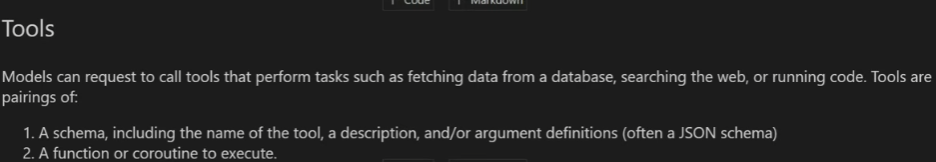

In [23]:
from langchain_groq import ChatGroq
llm = ChatGroq(
    model = "llama-3.1-8b-instant",
    temperature= 2)

In [25]:
from langchain.tools import tool

@tool
def get_weather(location:str) -> str:
    """Current Weather in the location"""
    return f"The weather currently in {location} is quite sunny"

model_with_tools = llm.bind_tools([get_weather])

In [8]:
"""response = model_with_tools.invoke("What is it like in Vizianagarm")
response"""

'response = model_with_tools.invoke("What is it like in Vizianagarm")\nresponse'

In [ ]:
"""response"""

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'q2xmdr15b', 'function': {'arguments': '{"location":"Vizianagarm"}', 'name': 'get_weather'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 230, 'total_tokens': 248, 'completion_time': 0.018819629, 'completion_tokens_details': None, 'prompt_time': 0.014631471, 'prompt_tokens_details': None, 'queue_time': 0.048836733, 'total_time': 0.0334511}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f8e21-60bb-73d1-9e6b-41e38422af62-0', tool_calls=[{'name': 'get_weather', 'args': {'location': 'Vizianagarm'}, 'id': 'q2xmdr15b', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 230, 'output_tokens': 18, 'total_tokens': 248})

In [ ]:
"""for tool_call in response.tool_calls:
    print(f"Tool: {tool_call['name']}")
    print(f"Args: {tool_call['args']}")"""

Tool: get_weather
Args: {'location': 'Vizianagarm'}


In [ ]:
"""llm.invoke("What is a carrot?")"""

AIMessage(content='A carrot is a root vegetable that belongs to the parsley family (Apiaceae). It is a long, thin, and tapering edible root that grows underground. Carrots are typically orange in color, but they can also be found in other colors such as yellow, white, red, purple, and even black.\n\nCarrots are a cool-season crop, which means they thrive in temperate climates with moderate temperatures and adequate moisture. They are a popular ingredient in many cuisines around the world and are often eaten raw or cooked in a variety of dishes, such as salads, stews, and soups.\n\nCarrots are a good source of nutrients, including:\n\n1. Fiber: Carrots are high in dietary fiber, which can help promote digestive health and support healthy blood sugar levels.\n2. Vitamins: Carrots are rich in vitamins A, C, and K, as well as other essential vitamins and minerals.\n3. Antioxidants: Carrots contain a range of antioxidants, including beta-carotene, which can help protect cells from damage an

In [26]:
from langchain_core.messages import ToolMessage
from pprint import pprint
messages = [{"role": "user","content":"How is the weather in Vizianagaram?"}]

# First model call
reply = model_with_tools.invoke(messages)

# Save assistant message
messages.append(reply)

# Execute every requested tool
for tool_call in reply.tool_calls:
    tool_result = get_weather.invoke(tool_call["args"])
    tool_message = ToolMessage(
        content=tool_result,
        tool_call_id=tool_call["id"]
    )
    messages.append(tool_message)
#messages.append({"role":"user","content":"Hi!"})
pprint(messages)
# Second model call
final_response = model_with_tools.invoke(messages)
print(final_response)
print(final_response.tool_calls)

[{'content': 'How is the weather in Vizianagaram?', 'role': 'user'},
 AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '0vkq28a25', 'function': {'arguments': '{"location":"Vizianagaram"}', 'name': 'get_weather'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 221, 'total_tokens': 239, 'completion_time': 0.019060336, 'completion_tokens_details': None, 'prompt_time': 0.014682855, 'prompt_tokens_details': None, 'queue_time': 0.205162832, 'total_time': 0.033743191}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_7ccc667439', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f8f3a-0140-7482-8465-2add203ef5bd-0', tool_calls=[{'name': 'get_weather', 'args': {'location': 'Vizianagaram'}, 'id': '0vkq28a25', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 221, 'output_tokens': 18, 'total_tokens': 239}),
 ToolMessag

In [12]:
final_response

AIMessage(content='', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 1, 'prompt_tokens': 237, 'total_tokens': 238, 'completion_time': 0.003351272, 'completion_tokens_details': None, 'prompt_time': 0.016072167, 'prompt_tokens_details': None, 'queue_time': None, 'total_time': 0.019423439}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_7ccc667439', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f8f37-3d58-7e82-a8d2-92413cb79572-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 237, 'output_tokens': 1, 'total_tokens': 238})